# Light Curve Viewer
Reads and plots the merged pipeline output for a given target and observation night.

In [8]:
# ── Parameters ─────────────────────────────────────────────────────────────────
# Edit these two values before running the notebook

TARGET   = "2001_FD58"     # Name of the target folder
NIGHT    = "26_03_06"   # Observation night folder (e.g. '2024-07-15')
MAIN_DIR = "data/"            # Path to the main folder containing target subfolders

In [9]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [10]:
# ── Locate the merged data file ────────────────────────────────────────────────

merged_file = "pipelineout_datasubset_all.dat"

if not os.path.isfile(merged_file):
    sys.exit(
        f"Merged file not found:\n  {merged_file}\n"
        "Run merge_pipeline_dat.py first, or check TARGET / NIGHT / MAIN_DIR."
    )

print(f"Reading: {merged_file}")

Reading: pipelineout_datasubset_all.dat


In [11]:
# ── Load data ──────────────────────────────────────────────────────────────────
# The header line starts with '#', so we strip that character for clean column names

df = pd.read_csv(merged_file, sep="\t", comment=None, header=0)

# Strip the leading '#' from the first column name
df.columns = [c.lstrip("#").strip() for c in df.columns]

print(f"Loaded {len(df)} rows.")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded 79 rows.
Columns: ['', 'Label', 'J.D.-2400000', 'rel_flux_T1', 'rel_flux_err_T1']


,,Label,J.D.-2400000,rel_flux_T1,rel_flux_err_T1
0,1,G2882-S001-R001-C001-R_out.fits,61106.504392,0.082415,0.005422
1,2,G2882-S001-R001-C002-R_out.fits,61106.505579,0.069970,0.004859
2,3,G2882-S001-R001-C003-R_out.fits,61106.506757,0.069374,0.004389
3,4,G2882-S001-R001-C004-R_out.fits,61106.507936,0.074252,0.004065
4,5,G2882-S001-R001-C005-R_out.fits,61106.509131,0.077099,0.003832


In [12]:
import sys, os

root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
sys.path.insert(0, root)

from utils.light_curve import sanity_check, plot_light_curve

In [13]:
sanity_check(df)

J.D.-2400000     : 61106.504392  →  61106.625215
rel_flux_T1      : 0.028921  →  0.082415
Median flux error: 0.003704


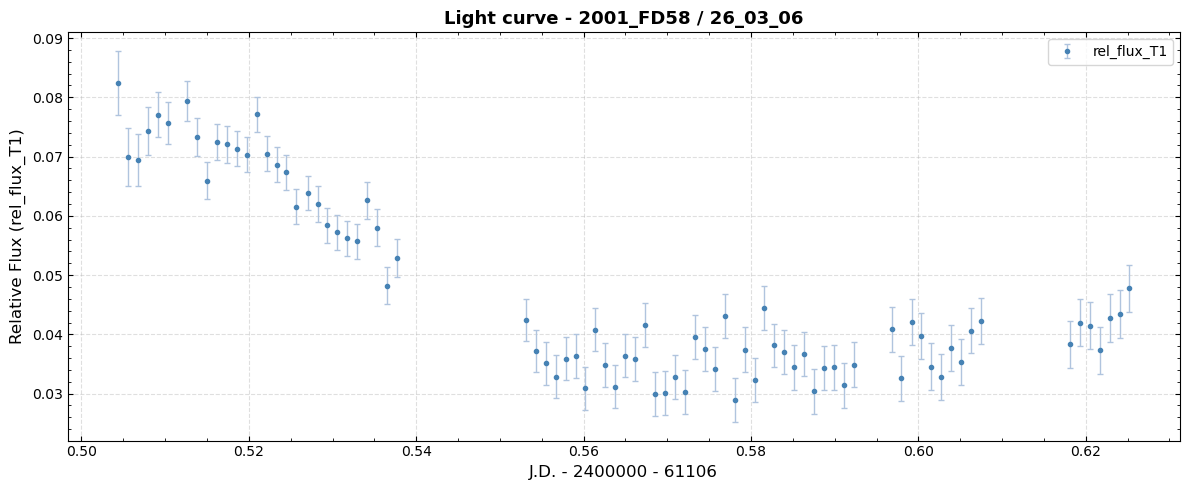

In [14]:
# T = 5.5

plot_light_curve(TARGET, NIGHT, df["J.D.-2400000"], df["rel_flux_T1"], df["rel_flux_err_T1"], period=None)